# 02 - TF-IDF lexical baseline on HC3

1. Load
2. Train, score and calibrate threshold
3. Score distributions
4. Results by domain
5. What the model relies on
6. Stability across splits
7. Is the training set large enough?
8. How much did length contribute?
9. Choosing the regularisation strength
10. Baseline with the chosen C

The lexical baseline is the simplest detector in the study: TF-IDF word unigrams and bigrams with logistic regression, following Solaiman et al. ("we released a simple classifier baseline that trains a logistic regression detector on TF-IDF unigram and bigram features.", They report that it scored between 74% and 97% accuracy on GPT-2 text, depending on the model size and how the text was generated.) It sets a floor for the other detectors and shows which surface cues separate the classes. This notebook trains it on the preprocessed HC3 corpus from `01`, measures TPR@1%FPR, and checks how stable and how trustworthy that number is.

## 1. Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, PredefinedSplit

from logos.project_data.hc3 import load_hc3, clean_hc3
from logos.project_data.preprocess import preprocess, train_val_split, length_match
from logos.models.tf_idf import lexical_baseline
from logos.evaluation.metrics import calibrate_threshold, tpr_at_threshold, fpr_at_threshold

hc3 = preprocess(clean_hc3(load_hc3()))
train_df, val_df = train_val_split(hc3, val_fraction=0.15)
train_df = length_match(train_df)
print("train:", train_df.shape, "| val:", val_df.shape)

train: (7788, 6) | val: (11708, 6)


## 2. Train, score and calibrate threshold
The model is trained on the length matched training set and scores every validation text with a probability of being ChatGPT. τ* is then set so that at most 1% of human validation texts score at or above it, and TPR@1%FPR is the share of ChatGPT texts at or above that threshold.

In [2]:
# 1. Train the model on the length-matched training texts
model = lexical_baseline()
model.fit(train_df["text"], train_df["label"])

# 2. Score every validation text: the probability that it's ChatGPT
probabilities = model.predict_proba(val_df["text"])
scores = probabilities[:, 1]

# 3. The true answers for the validation texts (0 = human, 1 = ChatGPT)
labels = val_df["label"].to_numpy()

# 4. Choose the cut-off that flags at most 1% of human texts
tau = calibrate_threshold(scores, labels, target_fpr=0.01)

# 5. Measure what that cut-off does
fpr = fpr_at_threshold(scores, labels, tau)
tpr = tpr_at_threshold(scores, labels, tau)

print("cut-off (tau*):", round(tau, 4))
print("humans wrongly flagged (FPR):", round(fpr, 4))
print("ChatGPT caught (TPR):", round(tpr, 4))

cut-off (tau*): 0.7089
humans wrongly flagged (FPR): 0.0099
ChatGPT caught (TPR): 0.7507


In [3]:
# 1. Which texts did the detector flag as ChatGPT? (True / False for each text)
flagged = scores >= tau

# 2. Which texts are actually human, and which are actually ChatGPT?
is_human = labels == 0
is_chatgpt = labels == 1

# 3. Count each group
n_humans = is_human.sum()
n_chatgpt = is_chatgpt.sum()

humans_wrongly_flagged = (flagged & is_human).sum()
chatgpt_caught = (flagged & is_chatgpt).sum()

print("humans wrongly flagged:", humans_wrongly_flagged, "of", n_humans)
print("ChatGPT caught:", chatgpt_caught, "of", n_chatgpt)

humans wrongly flagged: 77 of 7785
ChatGPT caught: 2945 of 3923


When this detector is set so that it wrongly accuses fewer than 1 in 100 human writers, it catches about 3 in 4 ChatGPT texts.

## 3. Score distributions
The two classes' scores, with τ* marked. Human texts to the right of the line are false positives; ChatGPT texts to its left are missed. The y-axis is logarithmic so the small tails near the threshold are visible.

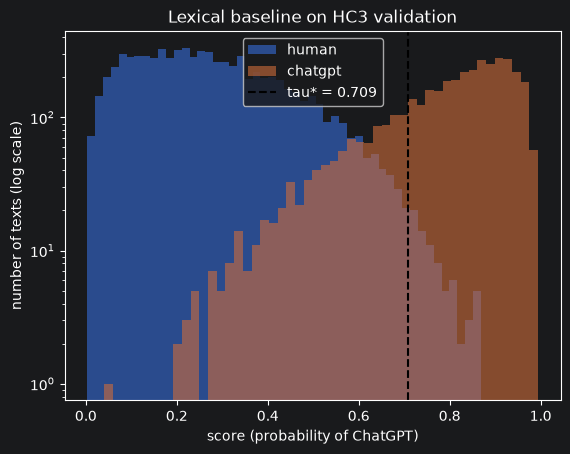

In [4]:
# 1. Split the scores into the two groups
human_scores = scores[labels == 0]
chatgpt_scores = scores[labels == 1]

# 2. Draw one histogram per group, on the same axes
plt.hist(human_scores, bins=50, alpha=0.6, label="human")
plt.hist(chatgpt_scores, bins=50, alpha=0.6, label="chatgpt")

# 3. Mark the cut-off with a dashed vertical line
plt.axvline(tau, color="black", linestyle="--", label=f"tau* = {round(tau, 3)}")

# 4. Labels and layout
plt.yscale("log")
plt.xlabel("score (probability of ChatGPT)")
plt.ylabel("number of texts (log scale)")
plt.title("Lexical baseline on HC3 validation")
plt.legend()
plt.show()

## 4. Results by domain
One threshold is applied to every domain, so the 1% false-positive budget is not shared evenly. `n_human` shows how many human texts each rate is based on.

In [5]:
# 1. Copy the validation data and mark which texts were flagged
val = val_df.copy()
val["flagged"] = scores >= tau

# 2. Split into human and ChatGPT texts
humans = val[val["label"] == 0]
chatgpt = val[val["label"] == 1]

# 3. Per domain: how many humans, and how many of them were wrongly flagged
n_human = humans.groupby("domain").size()
humans_flagged = humans.groupby("domain")["flagged"].sum()
fpr = humans.groupby("domain")["flagged"].mean()

# 4. Per domain: share of ChatGPT texts caught
tpr = chatgpt.groupby("domain")["flagged"].mean()

# 5. Put the columns side by side in one table
by_domain = pd.DataFrame({
    "n_human": n_human,
    "humans_flagged": humans_flagged,
    "FPR": fpr,
    "TPR": tpr,
})
by_domain

,n_human,humans_flagged,FPR,TPR
domain,,,,
finance,571,3,0.005254,0.844214
medicine,198,0,0.000000,0.982759
open_qa,152,14,0.092105,0.473581
reddit_eli5,6753,58,0.008589,0.773770
wiki_csai,111,2,0.018018,0.604839


Four domains sit at or near the 1% budget: finance 0.5%, medicine 0%, reddit_eli5 0.9%, and wiki_csai 1.8% (2 of 111 texts). open_qa is the exception at 9.2% (14 of 152), and it also has the lowest TPR (0.47). Its human answers are short, single-sentence statements, and only 53 open_qa pairs survive length matching, so the model has seen little of this domain. TPR varies widely across the others too, from 0.60 (wiki_csai) to 0.98 (medicine).

It is worth reading the open_qa false positives:

In [6]:
# 1. Human texts that the detector wrongly flagged
false_positives = humans[humans["flagged"]]

# 2. Keep only the open_qa ones
open_qa_false_positives = false_positives[false_positives["domain"] == "open_qa"]

# 3. Print the first 300 characters of each
for text in open_qa_false_positives["text"]:
    print("•", text[:300], "\n")

• Franklin Delano Roosevelt (or; January 30, 1882 – April 12, 1945), also known by his initials, FDR, was the 32nd President of the United States (1933–1945) and a central figure in world events during the mid-20th century, leading the United States during a time of worldwide economic depression and t 

• The Preamble to the United States Constitution is a brief introductory statement of the Constitution's fundamental purposes and guiding principles. 

• As seen from the Earth, a solar eclipse occurs when the Moon passes between the Sun and Earth, and the Moon fully or partially blocks (" occults ") the Sun. 

• It has been listed as endangered on the United States Fish and Wildlife Service list of endangered species since 8 August 1991. 

• Roosevelt, Jr. (; October 27, 1858—January 6, 1919) was the 26th President of the United States (1901–1909). 

• Pigs are omnivores and are highly social and intelligent animals. 

• Trin-i-tee 5:7 is a gospel duo from New Orleans, Louisiana in the

All 14 are encyclopaedia-style definitions: formal, factual sentences with none of the informal markers the model associates with human writing (basically, just, my, contractions). 9 of them contain "the United States", a phrase among the model's strongest ChatGPT features. The model learned a formality cue from informal reddit answers, and it misfires on formal human text.

## 5. What the model relies on
Logistic regression gives each word or word pair a weight. The most negative weights push towards "human", the most positive towards "ChatGPT".

In [7]:
# 1. The two steps inside the model, by name
tfidf = model.named_steps["tfidfvectorizer"]
logreg = model.named_steps["logisticregression"]

# 2. Every word or word pair the model knows, and the weight it gave each one
words = tfidf.get_feature_names_out()
weights = logreg.coef_[0]

# 3. Put them in a table, sorted from most human to most ChatGPT
feature_weights = pd.DataFrame({"feature": words, "weight": weights})
feature_weights = feature_weights.sort_values("weight")

# 4. The two ends of the table
print("Most human-indicative:")
print(feature_weights.head(25))

print("Most ChatGPT-indicative:")
print(feature_weights.tail(25).iloc[::-1])

Most human-indicative:
         feature    weight
6151         but -4.940442
31240         so -4.048885
41885        you -3.763435
11792        etc -3.750982
22504         my -3.345478
1148         all -3.340804
40580       what -3.298437
19246       just -3.261703
24908       only -3.190582
22195       most -3.090167
22918         no -3.072638
36267       then -2.996079
23323        now -2.951493
4624   basically -2.811905
1539          an -2.775363
37016      those -2.722183
36348      there -2.719640
28430         re -2.692858
41230       with -2.648733
10674        don -2.625394
14300        get -2.592350
13806       from -2.586635
41043       will -2.463938
18617        isn -2.449408
30953      since -2.430842
Most ChatGPT-indicative:
            feature    weight
16581     important  4.093378
16606  important to  4.071342
18853         it is  3.726197
15767         helps  3.258195
6571            can  3.220781
15712          help  3.214187
21633         might  3.205405
25091     

The human-indicative features are conversational words (but, so, you, my, just, basically, etc) and pieces of contractions (re, don, isn). The ChatGPT-indicative features are hedged, explanatory phrases (important to, it is, might, may, such as, means that, overall). No tokenisation artefacts remain.

Two ChatGPT features are not about writing style. "sure" and "have any" come from ChatGPT's chat habits (opening with "Sure!" and closing with "if you have any questions"), so they are tied to this generator in this setting and are unlikely to carry over to others. "the united" is the phrase that was flagged on formal human text in open_qa.

The model separates informal from formal writing more than human from machine, but it may not work well with changes to the generator or register.

## 6. Stability across splits
One split gives one number. Repeating over five seeds shows how much TPR and τ* move depending on which texts land in validation, and so how large a difference between detectors has to be before it means anything. FPR is identical each time because the calibration always allows the same number of human texts above τ*.

In [8]:
results = []

for seed in range(5):
    # 1. Split and length-match, with this seed's shuffle
    seed_train, seed_val = train_val_split(hc3, val_fraction=0.15, seed=seed)
    seed_train = length_match(seed_train)

    # 2. Train
    seed_model = lexical_baseline(seed=seed)
    seed_model.fit(seed_train["text"], seed_train["label"])

    # 3. Score the validation texts
    seed_scores = seed_model.predict_proba(seed_val["text"])[:, 1]
    seed_labels = seed_val["label"].to_numpy()

    # 4. Choose the cut-off and measure
    seed_tau = calibrate_threshold(seed_scores, seed_labels, target_fpr=0.01)
    seed_fpr = fpr_at_threshold(seed_scores, seed_labels, seed_tau)
    seed_tpr = tpr_at_threshold(seed_scores, seed_labels, seed_tau)

    # 5. Record this round
    results.append({"seed": seed, "tau": seed_tau, "FPR": seed_fpr, "TPR": seed_tpr})

results = pd.DataFrame(results)
display(results)

# Average and spread across the five rounds
results[["tau", "TPR"]].agg(["mean", "std"])

,seed,tau,FPR,TPR
0,0,0.708944,0.009891,0.750701
1,1,0.726408,0.009891,0.711700
2,2,0.701092,0.009891,0.753250
3,3,0.717141,0.009891,0.718328
4,4,0.712225,0.009891,0.730308


,tau,TPR
mean,0.713162,0.732858
std,0.009429,0.018705


TPR@1%FPR = 0.733 ± 0.019 over five seeds. Differences between detectors smaller than about two standard deviations (roughly 4 points) should not be read as real.

## 7. Is the training set large enough?
Length matching reduces the training split from 66,341 texts to 7,788. To see whether more data would still help, the model is trained on growing subsets (1,000, 2,000, 4,000, and the full 7,788, roughly doubling each time), and every version is scored on the same validation set.

In [9]:
# 1. One split for every size, so they're all tested on the same validation texts
curve_train, curve_val = train_val_split(hc3, val_fraction=0.15)
curve_train = length_match(curve_train)
curve_labels = curve_val["label"].to_numpy()

sizes = [1000, 2000, 4000, len(curve_train)]
curve = []

for size in sizes:
    # 2. Take a balanced subset: half human, half ChatGPT
    per_class = size // 2
    subset = curve_train.groupby("label", group_keys=False).sample(n=per_class, random_state=0)

    # 3. Train on the subset and score the validation texts
    curve_model = lexical_baseline()
    curve_model.fit(subset["text"], subset["label"])
    curve_scores = curve_model.predict_proba(curve_val["text"])[:, 1]

    # 4. Choose the cut-off and measure
    curve_tau = calibrate_threshold(curve_scores, curve_labels, target_fpr=0.01)
    curve_tpr = tpr_at_threshold(curve_scores, curve_labels, curve_tau)

    curve.append({"n_train": size, "TPR@1%FPR": curve_tpr})

curve = pd.DataFrame(curve)
curve

,n_train,TPR@1%FPR
0,1000,0.564109
1,2000,0.621208
2,4000,0.674739
3,7788,0.750701


<Axes: xlabel='n_train', ylabel='TPR@1%FPR'>

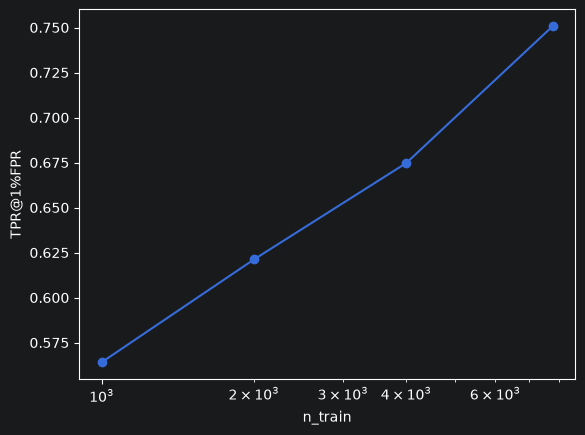

In [10]:
curve.plot(x="n_train", y="TPR@1%FPR", marker="o", logx=True, legend=False, ylabel="TPR@1%FPR")

TPR rises by roughly 5–8 points with each doubling and has not levelled off at the full set, so the baseline is data-limited on HC3. This limits the development runs only: the reported experiments train on MAGE, which is far larger.

## 8. How much did length contribute?
Length matching removes length as a clue, but it also shrinks the training set from 66341 texts to 7859.6 on average across five seeds (7788 for seed 0). To separate the two effects, three training sets are compared, each scored on the same natural-length validation set over five seeds:

- **matched**: the length-matched set;
- **unmatched, same size**: a random sample of the same size and class balance as that seed's matched set, with lengths left as they are;
- **unmatched, full**: the whole training split (66341 texts).

In [11]:
comparison = []

for seed in range(5):
    # 1. Split with this seed's shuffle
    cmp_train, cmp_val = train_val_split(hc3, val_fraction=0.15, seed=seed)
    cmp_labels = cmp_val["label"].to_numpy()

    # 2. Build the three training sets
    matched = length_match(cmp_train)
    per_class = len(matched) // 2
    same_size = cmp_train.groupby("label", group_keys=False).sample(n=per_class, random_state=seed)

    training_sets = {
        "matched": matched,
        "unmatched, same size": same_size,
        "unmatched, full": cmp_train,
    }

    # 3. Train and score each one on the same validation texts
    for name, training_set in training_sets.items():
        cmp_model = lexical_baseline(seed=seed)
        cmp_model.fit(training_set["text"], training_set["label"])
        cmp_scores = cmp_model.predict_proba(cmp_val["text"])[:, 1]

        cmp_tau = calibrate_threshold(cmp_scores, cmp_labels, target_fpr=0.01)
        cmp_tpr = tpr_at_threshold(cmp_scores, cmp_labels, cmp_tau)

        comparison.append({"seed": seed, "train": name, "n": len(training_set), "TPR": cmp_tpr})

comparison = pd.DataFrame(comparison)
comparison.groupby("train")[["n", "TPR"]].agg(["mean", "std"])

n                  TPR          
                         mean        std      mean       std
train                                                       
matched                7859.6  43.113803  0.732858  0.018705
unmatched, full       66341.0   0.000000  0.929136  0.005832
unmatched, same size   7859.6  43.113803  0.805812  0.008953

At equal size and class balance, the unmatched model scores around 7 points higher than the matched one (0.806 vs 0.733): that much of the baseline's in-distribution TPR came from length. Because matched pairs are a selected subset, this is an upper bound. The remaining gap to the full unmatched set (0.929) is training-set size. In-distribution, a length shortcut helps, because validation shares the training set's length bias; it is the kind of cue expected to fail under generator shift.

In [12]:
# 1. One split, used for both training sets
fp_train, fp_val = train_val_split(hc3, val_fraction=0.15, seed=0)
fp_labels = fp_val["label"].to_numpy()

training_sets = {
    "unmatched, full": fp_train,
    "matched": length_match(fp_train),
}

fp_rate = {}
fp_count = {}

for name, training_set in training_sets.items():
    # 2. Train and score
    fp_model = lexical_baseline()
    fp_model.fit(training_set["text"], training_set["label"])
    fp_scores = fp_model.predict_proba(fp_val["text"])[:, 1]

    # 3. Choose the cut-off and mark which texts are flagged
    fp_tau = calibrate_threshold(fp_scores, fp_labels, target_fpr=0.01)
    fp_flagged = fp_val.assign(flagged=fp_scores >= fp_tau)

    # 4. Keep the human texts, and measure per domain
    fp_humans = fp_flagged[fp_flagged["label"] == 0]
    fp_rate[name] = fp_humans.groupby("domain")["flagged"].mean()
    fp_count[name] = fp_humans.groupby("domain")["flagged"].sum()

print("Humans wrongly flagged (count):")
display(pd.DataFrame(fp_count))

print("Humans wrongly flagged (rate):")
pd.DataFrame(fp_rate)

Humans wrongly flagged (count):


,"unmatched, full",matched
domain,,
finance,4,3
medicine,0,0
open_qa,7,14
reddit_eli5,47,58
wiki_csai,19,2


Humans wrongly flagged (rate):


,"unmatched, full",matched
domain,,
finance,0.007005,0.005254
medicine,0.000000,0.000000
open_qa,0.046053,0.092105
reddit_eli5,0.006960,0.008589
wiki_csai,0.171171,0.018018


Length matching changes which human texts are wrongly flagged, not how many: the threshold allows 77 in both cases. wiki_csai's human texts are long, formal Wikipedia paragraphs: the unmatched model flags 19 of 111 (17%), the matched model 2 (1.8%). open_qa moves the other way, from 7 of 152 (4.6%) to 14 (9.2%), because its human answers are short. The length shortcut was penalising long human writing and protecting short human writing; matching removes both effects. wiki_csai's earlier disparity was mostly length, not register.

## 9. Choosing the regularisation strength
C controls how closely logistic regression may fit the training data (higher means less regularisation). Following [50], C is chosen from the grid 1/64 to 64 using a single held-out tuning split. The tuning split is derived from the training data, so the validation set is used only for τ*.

In [13]:
# 1. Split off validation, length-match training, then carve a tuning split from training
c_train, c_val = train_val_split(hc3, val_fraction=0.15)
c_train = length_match(c_train)
fit_df, tune_df = train_val_split(c_train, val_fraction=0.15)

# 2. Stack the fitting and tuning texts into one pile, as the search tool expects
X = pd.concat([fit_df["text"], tune_df["text"]])
y = pd.concat([fit_df["label"], tune_df["label"]])

# 3. Tag each row: -1 = always train on it, 0 = test on it
fit_tags = [-1] * len(fit_df)
tune_tags = [0] * len(tune_df)
split = PredefinedSplit(fit_tags + tune_tags)

# 4. The values of C to try: 1/64, 1/32, ... 32, 64
C_grid = [2.0 ** i for i in range(-6, 7)]
param_grid = {"logisticregression__C": C_grid}

# 5. Try every C: train on the fitting rows, score on the tuning rows
search = GridSearchCV(lexical_baseline(), param_grid, cv=split, refit=False, n_jobs=4)
search.fit(X, y)

# 6. Results as a table
c_results = pd.DataFrame({
    "C": C_grid,
    "tune accuracy": search.cv_results_["mean_test_score"],
})
c_results["correct"] = (c_results["tune accuracy"] * len(tune_df)).round().astype(int)
c_results["of"] = len(tune_df)

print("best C:", search.best_params_["logisticregression__C"])
c_results

best C: 64.0


,C,tune accuracy,correct,of
0,0.015625,0.861420,1007,1169
1,0.031250,0.869119,1016,1169
2,0.062500,0.877673,1026,1169
3,0.125000,0.897348,1049,1169
4,0.250000,0.911035,1065,1169
5,0.500000,0.925577,1082,1169
6,1.000000,0.941831,1101,1169
7,2.000000,0.947819,1108,1169
8,4.000000,0.949530,1110,1169
9,8.000000,0.952096,1113,1169


Accuracy on the tuning split (1,169 texts) rises across the whole grid, from 86.1% at C = 1/64 to 95.8% at C = 64, the top of the grid. Most of the gain comes below C = 8; from C = 8 to C = 64 accuracy improves by 0.6 points, 7 texts. C = 64 is used. Because it sits at the edge of the grid, a larger value might do marginally better, and because the search optimises accuracy rather than TPR@1%FPR, section 10 checks that the choice also improves the target metric.

## 10. Baseline with the chosen C

In [14]:
# 1. Use the C chosen by the search in the previous cell
best_C = search.best_params_["logisticregression__C"]

final = []

for seed in range(5):
    # 2. Split and length-match, with this seed's shuffle
    final_train, final_val = train_val_split(hc3, val_fraction=0.15, seed=seed)
    final_train = length_match(final_train)

    # 3. Train with the chosen C and score the validation texts
    final_model = lexical_baseline(C=best_C, seed=seed)
    final_model.fit(final_train["text"], final_train["label"])
    final_scores = final_model.predict_proba(final_val["text"])[:, 1]
    final_labels = final_val["label"].to_numpy()

    # 4. Choose the cut-off and measure
    final_tau = calibrate_threshold(final_scores, final_labels, target_fpr=0.01)
    final_tpr = tpr_at_threshold(final_scores, final_labels, final_tau)

    final.append({"seed": seed, "tau": final_tau, "TPR": final_tpr})

final = pd.DataFrame(final)

# 5. Put each seed next to its default-C result from section 6
paired = final.merge(results[["seed", "TPR"]], on="seed", suffixes=(" (C=64)", " (C=1)"))
paired["change"] = paired["TPR (C=64)"] - paired["TPR (C=1)"]
display(paired)

final[["tau", "TPR"]].agg(["mean", "std"])

,seed,tau,TPR (C=64),TPR (C=1),change
0,0,0.928663,0.789702,0.750701,0.039001
1,1,0.924192,0.795565,0.711700,0.083864
2,2,0.910963,0.810094,0.753250,0.056844
3,3,0.933447,0.761917,0.718328,0.043589
4,4,0.916142,0.798369,0.730308,0.068060


,tau,TPR
mean,0.922681,0.791129
std,0.009138,0.017938


With C = 64, TPR@1%FPR is 0.791 ± 0.018 over five seeds, against 0.733 ± 0.019 at the default C = 1. Because each seed uses the same split under both settings, the comparison is paired: C = 64 is better on all five seeds, by 3.9 to 8.4 points. τ* rises from about 0.71 to about 0.92 because a less regularised model gives more extreme scores; τ* values are not comparable across models, only the TPR they produce. Sections 2 to 8 use the default C; this is the tuned baseline.

## Observations

### Setup

The baseline (TF-IDF unigrams and bigrams with logistic regression [50]) is trained on the length-matched training split (7788 texts for seed 0) and calibrated on the natural-length validation split (11708 texts: 7785 human, 3923 ChatGPT).

### Headline (seed 0, default C)

τ* = 0.7089 flags 77 of 7,785 human texts (0.99%) and catches 2,945 of 3,923 ChatGPT texts (TPR 75.1%).

### By domain

The 1% budget is not shared evenly. Humans wrongly flagged: finance 3 of 571, medicine 0 of 198, open_qa 14 of 152 (9.2%), reddit_eli5 58 of 6,753, wiki_csai 2 of 111. reddit_eli5 holds 87% of human validation texts and so effectively sets the threshold. TPR ranges from 47% (open_qa) to 98% (medicine). open_qa is weakest in both directions: its human answers are short, and only 53 open_qa pairs survive length matching.

### What the false positives look like

All 14 open_qa false positives are encyclopaedia-style definitions, formal and free of informal markers; 9 contain "the United States", one of the model's strongest ChatGPT features. The model has learned a formality cue from informal reddit answers that misfires on formal human writing.

### What the model relies on

Human features are conversational (but, so, you, my, just, basically) or pieces of contractions (re, don, isn). ChatGPT features are hedged, explanatory phrases (important to, it is, might, may, such as, means that, overall). "sure" and "have any" reflect ChatGPT's chat habits rather than its writing style, and are unlikely to carry over to other generators. No tokenisation artefacts remain.

### Stability

Across five seeds, TPR@1%FPR = 0.733 ± 0.019 (range 0.712 to 0.753) and τ* ranges from 0.701 to 0.726. Differences between detectors smaller than about 4 points should not be read as real.

### Training size

TPR rises from 56.4% (1000 texts) to 62.1% (2000), 67.5% (4000) and 75.1% (7788): 5 to 8 points per doubling, with no sign of levelling off. The baseline is data-limited on HC3; the reported experiments train on MAGE, which is far larger.

### Length

At equal size and class balance, unmatched training scores 0.806 against 0.733 matched, so up to around 7 points of in-distribution TPR came from length; full unmatched training scores 0.929, the rest of the gap being training size. Matching changes which humans are wrongly flagged, not how many (77 either way): wiki_csai's long human texts fall from 19 flagged to 2, while open_qa's short ones rise from 7 to 14. The length shortcut penalised long human writing and protected short human writing.

### Regularisation

C = 64 was chosen from the grid 1/64 to 64 on a tuning split of 1,169 texts carved from training. Tuning accuracy rose from 86.1% to 95.8%, with only 7 texts' difference between C = 8 and C = 64. C = 64 lies at the edge of the grid.

### Result

The tuned baseline scores TPR@1%FPR = 0.791 ± 0.018 over five seeds, better than the default C on every seed (by 3.9 to 8.4 points).

### Carried forward

- C is re-tuned on each MAGE training fold rather than fixed at 64, because the best value depends on training size.
- The baseline separates informal from formal writing as much as human from machine. This is the kind of cue expected to fail under generator shift, and the other detectors will be compared against it on that basis.